# The AI Confidence Trap
## La IA no es el problema. La dependencia pasiva si.

Este notebook esta disenado para una entrega de **data storytelling**. La intencion no es hacer un modelo complejo, sino construir una historia clara con visualizaciones simples.

**Big Idea**  
En este dataset real, el uso intensivo de IA no parece ser el problema por si solo. La diferencia aparece cuando comparamos a estudiantes que usan IA y siguen construyendo habilidades propias frente a estudiantes que usan IA intensivamente pero muestran bajo aprendizaje autonomo, menor claridad profesional y mayor ansiedad.

**Audiencia:** servicios de carrera, profesores, coordinadores academicos y equipos de exito estudiantil.  
**Accion esperada:** ensenar a usar IA como herramienta para construir habilidades, no como reemplazo del pensamiento propio.

> Nota importante: el analisis es exploratorio y no establece causalidad.


## 1. Setup y carga de datos

Cargamos el dataset, revisamos su estructura y aplicamos una limpieza mínima para poder graficar sin errores.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11

# Color oficial de enfasis del documento.
OFFICIAL_BLUE = "#2b9cff"

# Use only the real dataset stored in this project folder.
PROJECT_DIR = Path(r"C:\Users\unbue\DataVizProject")
DATA_PATH = PROJECT_DIR / "ai_dependency_career_anxiety_students.csv"
FIG_DIR = PROJECT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")

# Load data from the local project folder only.
df = pd.read_csv(DATA_PATH)

# The local CSV has padded column names and a leading "<<" in the first header.
# Normalize those labels so the rest of the notebook can use the intended variable names.
df.columns = [col.strip().lstrip("<").strip() for col in df.columns]

# Normalize text values and recover numeric columns from the padded CSV format.
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].astype(str).str.strip()

# Convert columns that are actually numeric but were read as text because of spacing.
for col in df.columns:
    if col == "student_id":
        continue
    numeric_version = pd.to_numeric(df[col], errors="coerce")
    if numeric_version.notna().mean() >= 0.95:
        df[col] = numeric_version

# Basic cleaning: fill numeric missing values with median and categorical missing values with "Not reported"
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna("Not reported")

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print("Missing values after cleaning:", int(df.isna().sum().sum()))
df.head()

C:\Users\unbue\AppData\Local\Temp\ipykernel_3732\452457266.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:


Dataset loaded from: C:\Users\unbue\DataVizProject\ai_dependency_career_anxiety_students.csv
Rows: 15,000
Columns: 30
Missing values after cleaning: 0


C:\Users\unbue\AppData\Local\Temp\ipykernel_3732\452457266.py:46: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,STU_00001,25,Male,B.Tech/B.E.,Engineering (Non-CS),3,Tier 3,Rural,0.3,Perplexity,...,3.5,8.7,2,1.5,8.5,1,3,6,0.0,9.09
1,STU_00002,20,Female,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Urban,1.9,ChatGPT,...,2.4,8.2,3,4.2,8.3,4,5,3,0.0,6.03
2,STU_00003,25,Female,MBA,CS/IT,1,Tier 3,Urban,3.6,Gemini,...,2.3,16.4,1,2.3,7.0,5,9,3,1.0,6.68
3,STU_00004,23,Male,B.Tech/B.E.,CS/IT,1,Tier 1,Urban,4.1,GitHub Copilot,...,7.7,15.0,3,2.6,7.2,6,6,6,0.0,7.71
4,STU_00005,22,Female,MBA,CS/IT,1,Tier 1,Urban,3.4,ChatGPT,...,2.4,1.1,2,1.9,8.0,3,5,4,0.0,4.64



## 2. Variables que usaremos en la historia

No vamos a usar todas las columnas. Para que la historia sea clara, nos enfocamos en tres bloques:

1. **Uso de IA:** `daily_ai_tool_usage_hrs`, `ai_dependency_score`, `ai_replaces_own_thinking_score`.
2. **Respuesta emocional/profesional:** `fear_of_job_loss_to_ai`, `placement_anxiety_score`, `burnout_score`, `motivation_score`.
3. **Construcción de habilidades:** `self_learning_hours_per_week`, `skill_development_courses_taken`, `internship_experience`, `career_clarity_score`, `overall_career_readiness_score`.


In [2]:

story_vars = [
    "daily_ai_tool_usage_hrs", "ai_dependency_score", "ai_replaces_own_thinking_score",
    "fear_of_job_loss_to_ai", "placement_anxiety_score", "burnout_score", "motivation_score",
    "self_learning_hours_per_week", "skill_development_courses_taken", "internship_experience",
    "career_clarity_score", "overall_career_readiness_score", "resume_confidence_score"
]

df[story_vars].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
daily_ai_tool_usage_hrs,15000.0,2.01,1.74,0.0,0.4,1.8,3.20,8.0
ai_dependency_score,15000.0,4.54,2.32,1.0,3.0,4.0,6.00,10.0
ai_replaces_own_thinking_score,15000.0,2.99,1.31,1.0,2.0,3.0,4.00,5.0
fear_of_job_loss_to_ai,15000.0,3.55,1.18,1.0,3.0,4.0,5.00,5.0
placement_anxiety_score,15000.0,5.91,2.55,1.0,4.0,6.0,8.00,10.0
burnout_score,15000.0,5.47,2.07,1.0,4.0,5.0,7.00,10.0
motivation_score,15000.0,4.32,2.15,1.0,3.0,4.0,6.00,10.0
self_learning_hours_per_week,15000.0,6.29,5.51,0.0,1.1,5.5,10.00,31.0
skill_development_courses_taken,15000.0,2.03,1.81,0.0,1.0,2.0,3.00,10.0
internship_experience,15000.0,1.72,1.07,0.0,1.0,2.0,2.00,4.0


## 3. Contexto inicial: del uso a la dependencia
### More AI hours are linked to higher dependency

Abrimos la historia con una secuencia muy simple: primero mostramos que, conforme suben las horas diarias de uso de IA, tambien sube el puntaje promedio de dependencia. Despues enfocamos la mirada en estudiantes que usan mas IA para mostrar el siguiente riesgo: cuando la dependencia aumenta, tambien aumenta la percepcion de que la IA reemplaza el pensamiento propio.

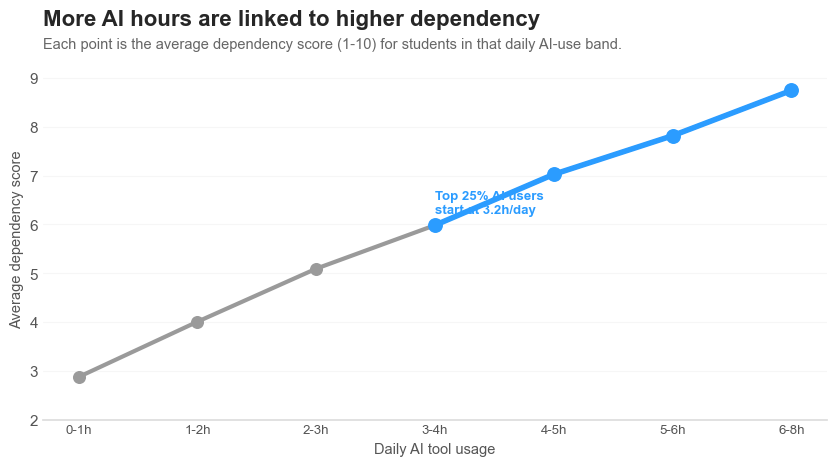

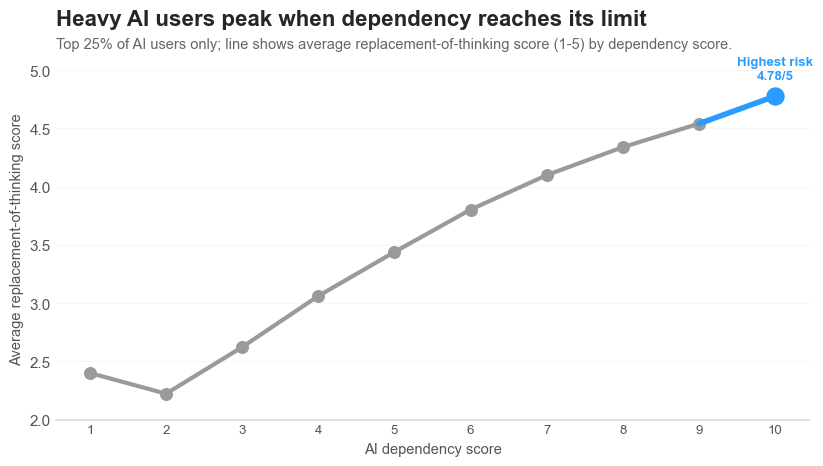

,ai_dependency_score,avg_replacement,avg_ai_hours,students
0,1,2.40,3.51,10
1,2,2.22,3.65,27
2,3,2.62,3.70,98
3,4,3.06,3.80,295
4,5,3.44,3.93,499
5,6,3.80,4.10,704
6,7,4.10,4.25,781
7,8,4.34,4.63,655
8,9,4.54,5.04,435
9,10,4.78,5.55,340


In [3]:
# =========================
# GRAFICAS 01 Y 02 - LINE GRAPHS LIMPIOS
# Que muestran: 1) uso diario de IA vs dependencia, 2) dependencia vs reemplazo del pensamiento.
# =========================

# =========================
# FUNCION EDITABLE PARA LINE GRAPHS
# Si quieres cambiar el diseno general de estas dos graficas, modifica clean_line_graph().
# =========================

def clean_line_graph(
    plot_df,
    x_col,
    y_col,
    title,
    subtitle,
    filename,
    x_label="",
    y_label="",
    line_color="#2b9cff",
    point_color=None,
    peak_x=None,
    peak_label="",
    peak_color="#2b9cff",
    base_line_color="#9a9a9a",
    highlight_peak=False,
    highlight_from_x=None,
    highlight_label="",
    figsize=(8.5, 4.8),
    y_limits=None,
    x_tick_rotation=0,
    line_width=3.0,
    point_size=70,
    peak_point_size=150,
    value_label_offset=0.10,
    title_fontsize=16,
    subtitle_fontsize=10.5,
    axis_label_fontsize=10.5,
    tick_fontsize=9.5,
    save_dpi=200
):
    """Dibuja una linea limpia con titulo, subtitulo y opcion de destacar un pico."""
    point_color = point_color or line_color
    fig, ax = plt.subplots(figsize=figsize)
    x_positions = np.arange(len(plot_df))
    y_values = plot_df[y_col].to_numpy()

    # Linea base: usa line_color para una linea completa azul o base_line_color si destacas solo el pico.
    current_line_color = base_line_color if highlight_peak else line_color
    ax.plot(
        x_positions,
        y_values,
        color=current_line_color,
        linewidth=line_width,
        marker="o",
        markersize=np.sqrt(point_size),
        markerfacecolor=current_line_color,
        markeredgecolor=current_line_color,
        solid_capstyle="round"
    )

    if highlight_from_x is not None:
        highlight_rows = plot_df.index[plot_df[x_col] == highlight_from_x].tolist()
        if highlight_rows:
            highlight_start = highlight_rows[0]
            highlight_x = x_positions[highlight_start:]
            highlight_y = y_values[highlight_start:]

            # Resalta el rango de interes sin mover datos: ultimo cuartil de uso de IA.
            ax.plot(
                highlight_x,
                highlight_y,
                color=peak_color,
                linewidth=line_width + 1.0,
                marker="o",
                markersize=np.sqrt(point_size * 1.35),
                markerfacecolor=peak_color,
                markeredgecolor=peak_color,
                solid_capstyle="round",
                zorder=4
            )
            if highlight_label:
                ax.text(
                    highlight_start,
                    highlight_y[0] + value_label_offset,
                    highlight_label,
                    ha="left",
                    va="bottom",
                    fontsize=tick_fontsize,
                    color=peak_color,
                    fontweight="bold"
                )

    if highlight_peak and peak_x is not None:
        peak_rows = plot_df.index[plot_df[x_col] == peak_x].tolist()
        if peak_rows:
            peak_idx = peak_rows[0]
            peak_y = plot_df.loc[peak_idx, y_col]

            # Destaca el tramo que llega al pico y el punto final, sin cambiar el dato real.
            if peak_idx > 0:
                ax.plot(
                    [peak_idx - 1, peak_idx],
                    [plot_df.loc[peak_idx - 1, y_col], peak_y],
                    color=peak_color,
                    linewidth=line_width + 1.0,
                    solid_capstyle="round",
                    zorder=4
                )
            ax.scatter(peak_idx, peak_y, s=peak_point_size, color=peak_color, zorder=5)
            ax.text(
                peak_idx,
                peak_y + value_label_offset,
                peak_label or f"Peak: {peak_y:.2f}",
                ha="center",
                va="bottom",
                fontsize=tick_fontsize,
                color=peak_color,
                fontweight="bold"
            )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(plot_df[x_col], rotation=x_tick_rotation, fontsize=tick_fontsize)
    ax.set_xlabel(x_label, fontsize=axis_label_fontsize, color="#555555")
    ax.set_ylabel(y_label, fontsize=axis_label_fontsize, color="#555555")
    if y_limits is not None:
        ax.set_ylim(*y_limits)

    ax.set_title(title, fontsize=title_fontsize, fontweight="bold", loc="left", pad=24)
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, ha="left", va="bottom",
            fontsize=subtitle_fontsize, color="#666666")

    ax.grid(axis="y", alpha=0.16, linewidth=0.8)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="both", length=0, colors="#555555")
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#dddddd")

    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=save_dpi, bbox_inches="tight")
    plt.show()


# =========================
# GRAFICA 01 - LINE GRAPH
# Que muestra: horas diarias de IA en relacion con dependencia.
# =========================

# --- VARIABLES: cambia estas columnas si quieres modificar la relacion principal.
ai_usage_col = "daily_ai_tool_usage_hrs"
dependency_col = "ai_dependency_score"

# --- AGRUPACION: cambia bins/labels para juntar o separar rangos de horas.
ai_hour_bins = [0, 1, 2, 3, 4, 5, 6, 8]
ai_hour_labels = ["0-1h", "1-2h", "2-3h", "3-4h", "4-5h", "5-6h", "6-8h"]

# --- TEXTOS Y STORYTELLING: cambia titulo, subtitulo y ejes.
chart_title = "More AI hours are linked to higher dependency"
chart_subtitle = "Each point is the average dependency score (1-10) for students in that daily AI-use band."
x_label = "Daily AI tool usage"
y_label = "Average dependency score"

# --- COLORES: gris para contexto; azul oficial para el ultimo cuartil.
line_color = "#9a9a9a"
point_color = "#9a9a9a"
quartile_color = OFFICIAL_BLUE

# --- ESPACIADO / TAMANO: cambia figura, limites y separacion visual.
fig_size = (8.5, 4.8)
y_limits = (2, 9.4)
highlight_from_x = "3-4h"
highlight_label = "Top 25% AI users\nstart at 3.2h/day"

# --- SALIDA: nombre del archivo generado.
output_filename = "01_line_ai_hours_dependency.png"

# --- CALCULOS: normalmente no necesitas tocar esto.
ai_dependency_by_hours = df.copy()
ai_dependency_by_hours["ai_hours_band"] = pd.cut(
    ai_dependency_by_hours[ai_usage_col],
    bins=ai_hour_bins,
    labels=ai_hour_labels,
    include_lowest=True,
    right=True
)

ai_dependency_by_hours = (
    ai_dependency_by_hours
    .groupby("ai_hours_band", observed=True)
    .agg(
        avg_dependency=(dependency_col, "mean"),
        students=(dependency_col, "size")
    )
    .reset_index()
)
ai_dependency_by_hours["ai_hours_band"] = ai_dependency_by_hours["ai_hours_band"].astype(str)

clean_line_graph(
    ai_dependency_by_hours,
    x_col="ai_hours_band",
    y_col="avg_dependency",
    title=chart_title,
    subtitle=chart_subtitle,
    filename=output_filename,
    x_label=x_label,
    y_label=y_label,
    line_color=line_color,
    point_color=point_color,
    peak_color=quartile_color,
    highlight_from_x=highlight_from_x,
    highlight_label=highlight_label,
    figsize=fig_size,
    y_limits=y_limits,
    value_label_offset=0.18
)

ai_dependency_by_hours.round(2)


# =========================
# GRAFICA 02 - LINE GRAPH CON PICO DESTACADO
# Que muestra: dependencia en relacion con reemplazo del pensamiento entre usuarios intensivos de IA.
# =========================

# --- VARIABLES: cambia columnas o filtro si quieres contar otra parte de la historia.
dependency_col = "ai_dependency_score"
replacement_col = "ai_replaces_own_thinking_score"
ai_usage_col = "daily_ai_tool_usage_hrs"
high_ai_cutoff = df[ai_usage_col].quantile(0.75)
high_ai_users = df[df[ai_usage_col] >= high_ai_cutoff].copy()

# --- TEXTOS Y STORYTELLING: cambia titulo, subtitulo y ejes.
chart_title = "Heavy AI users peak when dependency reaches its limit"
chart_subtitle = "Top 25% of AI users only; line shows average replacement-of-thinking score (1-5) by dependency score."
x_label = "AI dependency score"
y_label = "Average replacement-of-thinking score"

# --- COLORES: gris base + un solo pico en azul oficial.
base_line_color = "#9a9a9a"
peak_color = OFFICIAL_BLUE

# --- ESPACIADO / TAMANO: cambia figura, limites y etiqueta del pico.
fig_size = (8.5, 4.8)
y_limits = (2, 5.1)
peak_label_template = "Highest risk\n{value:.2f}/5"
value_label_offset = 0.12

# --- SALIDA: nombre del archivo generado.
output_filename = "02_line_dependency_replacement_high_ai.png"

# --- CALCULOS: normalmente no necesitas tocar esto.
dependency_replacement_high_ai = (
    high_ai_users
    .groupby(dependency_col, as_index=False)
    .agg(
        avg_replacement=(replacement_col, "mean"),
        avg_ai_hours=(ai_usage_col, "mean"),
        students=(replacement_col, "size")
    )
    .sort_values(dependency_col)
)
peak_row = dependency_replacement_high_ai.loc[dependency_replacement_high_ai["avg_replacement"].idxmax()]
peak_x = peak_row[dependency_col]
peak_label = peak_label_template.format(value=peak_row["avg_replacement"])

clean_line_graph(
    dependency_replacement_high_ai,
    x_col=dependency_col,
    y_col="avg_replacement",
    title=chart_title,
    subtitle=chart_subtitle,
    filename=output_filename,
    x_label=x_label,
    y_label=y_label,
    line_color=base_line_color,
    base_line_color=base_line_color,
    peak_x=peak_x,
    peak_label=peak_label,
    peak_color=peak_color,
    highlight_peak=True,
    figsize=fig_size,
    y_limits=y_limits,
    value_label_offset=value_label_offset
)

dependency_replacement_high_ai.round(2)

## 4. Comparacion 1: uso intensivo de IA con o sin aprendizaje autonomo
### Self-learning gives high-AI students clearer direction

El primer giro de la historia es que alto uso de IA no significa una sola cosa. Entre estudiantes con alto uso de IA, el aprendizaje autonomo aparece asociado con mas claridad de carrera. Por eso la linea azul destaca **Career clarity**.

In [4]:

# Cutoffs used only to create clear comparison groups
high_ai_cutoff = df["daily_ai_tool_usage_hrs"].quantile(0.75)
low_self_cutoff = df["self_learning_hours_per_week"].quantile(0.25)
high_self_cutoff = df["self_learning_hours_per_week"].quantile(0.75)

high_ai = df[df["daily_ai_tool_usage_hrs"] >= high_ai_cutoff].copy()

ai_low_self = high_ai[high_ai["self_learning_hours_per_week"] <= low_self_cutoff]
ai_high_self = high_ai[high_ai["self_learning_hours_per_week"] >= high_self_cutoff]

print(f"High AI use cutoff: {high_ai_cutoff:.2f} hours/day")
print(f"Low self-learning cutoff: <= {low_self_cutoff:.2f} hours/week")
print(f"High self-learning cutoff: >= {high_self_cutoff:.2f} hours/week")
print(f"High AI + low self-learning students: {len(ai_low_self):,}")
print(f"High AI + high self-learning students: {len(ai_high_self):,}")


High AI use cutoff: 3.20 hours/day
Low self-learning cutoff: <= 1.10 hours/week
High self-learning cutoff: >= 10.00 hours/week
High AI + low self-learning students: 321
High AI + high self-learning students: 1,785


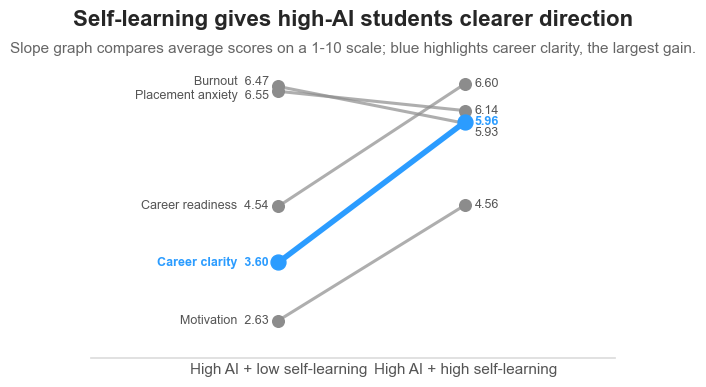

,metric,High AI + low self-learning,High AI + high self-learning,difference
0,Career readiness,4.54,6.60,2.05
1,Career clarity,3.60,5.96,2.36
2,Motivation,2.63,4.56,1.93
3,Placement anxiety,6.55,5.93,-0.62
4,Burnout,6.47,6.14,-0.32


In [5]:
# =========================
# FUNCIONES PARA COMPARACIONES Y SLOPE GRAPHS
# Si quieres cambiar el diseno general de TODOS los slope graphs, cambia la funcion slope_graph().
# Si solo quieres cambiar una grafica especifica, modifica el bloque CONFIGURA AQUI de esa grafica.
# =========================

def create_comparison_df(group_a, group_b, label_a, label_b, metrics, metric_labels):
    """Crea una tabla con el promedio de cada metrica para dos grupos."""
    rows = []
    for metric in metrics:
        rows.append({
            "metric": metric_labels.get(metric, metric),
            label_a: group_a[metric].mean(),
            label_b: group_b[metric].mean(),
            "difference": group_b[metric].mean() - group_a[metric].mean()
        })
    return pd.DataFrame(rows)


def slope_graph(
    comp_df,
    label_left,
    label_right,
    title,
    filename,
    subtitle="",
    left_color="#8c8c8c",
    right_color="#8c8c8c",
    down_color="#8c8c8c",
    line_color_overrides=None,
    label_y_offsets=None,
    right_value_y_offsets=None,
    subtitle_color="#666666",
    label_color="#555555",
    figsize=(7, 4),
    y_limits=(0, 10),
    x_limits=(-0.55, 1.35),
    line_width=2.2,
    line_alpha=0.70,
    point_size=70,
    emphasis_line_width=4.0,
    emphasis_point_size=115,
    left_label_offset=-0.05,
    right_label_offset=0.05,
    label_fontsize=9,
    title_fontsize=16,
    subtitle_fontsize=11,
    axis_label_fontsize=11,
    grid_alpha=0,
    title_pad=24,
    y_axis_label="",
    save_dpi=200
):
    """Dibuja un line slope graph limpio y editable.

    - line_color_overrides: cambia el color de una linea especifica.
      Ejemplo: {"Career readiness": OFFICIAL_BLUE}
    - label_y_offsets: mueve SOLO las etiquetas izquierdas.
    - right_value_y_offsets: mueve SOLO los numeros derechos.
    - y_axis_label="": quita el label del eje Y para un estilo mas editorial.
    """
    if line_color_overrides is None:
        line_color_overrides = {}
    if label_y_offsets is None:
        label_y_offsets = {}
    if right_value_y_offsets is None:
        right_value_y_offsets = {}

    plot_df = comp_df.copy()
    fig, ax = plt.subplots(figsize=figsize)
    x_left, x_right = 0, 1

    for _, row in plot_df.iterrows():
        metric_name = row["metric"]
        base_color = right_color if row[label_right] >= row[label_left] else down_color
        color = line_color_overrides.get(metric_name, base_color)
        is_emphasized = metric_name in line_color_overrides

        current_line_width = emphasis_line_width if is_emphasized else line_width
        current_point_size = emphasis_point_size if is_emphasized else point_size
        current_alpha = 1.0 if is_emphasized else line_alpha
        current_zorder = 5 if is_emphasized else 3

        # Puntos y linea usan valores reales; los offsets solo mueven texto.
        ax.plot(
            [x_left, x_right],
            [row[label_left], row[label_right]],
            color=color,
            linewidth=current_line_width,
            alpha=current_alpha,
            solid_capstyle="round",
            zorder=current_zorder
        )
        ax.scatter(
            [x_left, x_right],
            [row[label_left], row[label_right]],
            color=color,
            s=current_point_size,
            zorder=current_zorder + 1
        )

        left_text_y_offset = label_y_offsets.get(metric_name, 0)
        right_text_y_offset = right_value_y_offsets.get(metric_name, 0)
        left_text_y = row[label_left] + left_text_y_offset
        right_text_y = row[label_right] + right_text_y_offset

        ax.text(
            x_left + left_label_offset,
            left_text_y,
            f"{metric_name}  {row[label_left]:.2f}",
            ha="right",
            va="center",
            fontsize=label_fontsize,
            color=color if is_emphasized else label_color,
            fontweight="bold" if is_emphasized else "normal"
        )
        ax.text(
            x_right + right_label_offset,
            right_text_y,
            f"{row[label_right]:.2f}",
            ha="left",
            va="center",
            fontsize=label_fontsize,
            color=color if is_emphasized else label_color,
            fontweight="bold" if is_emphasized else "normal"
        )

    ax.set_xlim(*x_limits)
    ax.set_ylim(*y_limits)
    ax.set_xticks([x_left, x_right])
    ax.set_xticklabels([label_left, label_right], fontsize=axis_label_fontsize)
    ax.set_ylabel(y_axis_label if y_axis_label else "", fontsize=axis_label_fontsize)
    ax.set_title(title, fontsize=title_fontsize, fontweight="bold", pad=title_pad)
    if subtitle:
        ax.text(0.5, 1.01, subtitle, transform=ax.transAxes, ha="center", va="bottom",
                fontsize=subtitle_fontsize, color=subtitle_color)

    ax.grid(axis="y", alpha=grid_alpha, linewidth=0.8)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="y", length=0, labelleft=False)
    ax.tick_params(axis="x", length=0, colors="#555555")
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#dddddd")

    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=save_dpi, bbox_inches="tight")
    plt.show()


# --- ETIQUETAS DE METRICAS: cambia el texto visible de cada variable en los slope graphs.
metric_labels = {
    "overall_career_readiness_score": "Career readiness",
    "career_clarity_score": "Career clarity",
    "motivation_score": "Motivation",
    "placement_anxiety_score": "Placement anxiety",
    "burnout_score": "Burnout"
}

# --- VARIABLES BASE: cambia esta lista si quieres que los slope graphs usen otras metricas.
core_metrics = list(metric_labels.keys())

# =========================
# GRAFICA 03 - SLOPE GRAPH
# Que muestra: alto uso de IA con bajo vs alto aprendizaje autonomo.
# =========================

# --- VARIABLES / GRUPOS: cambia grupos o metricas a comparar.
left_group = ai_low_self
right_group = ai_high_self
left_label = "High AI + low self-learning"
right_label = "High AI + high self-learning"
metrics_to_plot = core_metrics

# --- TEXTOS Y SALIDA: cambia titulo, subtitulo y archivo PNG generado.
chart_title = "Self-learning gives high-AI students clearer direction"
chart_subtitle = "Slope graph compares average scores on a 1-10 scale; blue highlights career clarity, the largest gain."
output_filename = "03_slope_high_ai_self_learning.png"

# --- COLORES GENERALES: gris base para lineas; usa line_color_overrides con OFFICIAL_BLUE para enfasis.
left_color = "#8c8c8c"
right_color = "#8c8c8c"
down_color = "#8c8c8c"
subtitle_color = "#666666"

# --- COLOR POR LINEA: solo una linea azul para contar la historia de esta slide.
line_color_overrides = {
    "Career clarity": OFFICIAL_BLUE,
}

# --- OFFSETS DE ETIQUETAS: mueve SOLO textos si se enciman. Positivo sube, negativo baja.
label_y_offsets = {
    "Burnout": 0.15,
    "Placement anxiety": -0.15,
}

# --- OFFSETS DE NUMEROS DERECHOS: mueve SOLO el numero final de la derecha.
right_value_y_offsets = {
    "Career clarity": 0,
    "Placement anxiety": -0.16,
}

# --- LABEL DEL EJE Y: deja "" para quitarlo y tener estilo mas limpio.
y_axis_label = ""

# --- ESPACIADO / TAMANO: modifica tamano, baseline del eje Y y espacio horizontal.
fig_size = (7, 4)
y_limits = (2, 7)
x_limits = (-1.00, 1.8)

comp_self_learning = create_comparison_df(
    left_group,
    right_group,
    left_label,
    right_label,
    metrics_to_plot,
    metric_labels
)

slope_graph(
    comp_self_learning,
    left_label,
    right_label,
    chart_title,
    output_filename,
    subtitle=chart_subtitle,
    left_color=left_color,
    right_color=right_color,
    down_color=down_color,
    line_color_overrides=line_color_overrides,
    subtitle_color=subtitle_color,
    label_y_offsets=label_y_offsets,
    right_value_y_offsets=right_value_y_offsets,
    y_axis_label=y_axis_label,
    figsize=fig_size,
    y_limits=y_limits,
    x_limits=x_limits
)

comp_self_learning.round(2)

**Insight:** Entre estudiantes con alto uso de IA, el aprendizaje autonomo cambia la interpretacion del uso de herramientas. La diferencia mas clara aparece en **career clarity**, que sube mas que las otras metricas.

## 5. Comparacion 2: miedo al reemplazo laboral con accion o sin accion
### Fear becomes useful when it is paired with action

Partimos de estudiantes con alto miedo a perder oportunidades por IA. La pregunta no es solo quien tiene miedo, sino quien convierte ese miedo en aprendizaje y cursos. La linea azul destaca **Motivation** porque es el cambio que mejor sostiene esta idea.

In [6]:

high_fear_cutoff = df["fear_of_job_loss_to_ai"].quantile(0.75)
low_courses_cutoff = df["skill_development_courses_taken"].quantile(0.25)
high_courses_cutoff = df["skill_development_courses_taken"].quantile(0.75)

high_fear = df[df["fear_of_job_loss_to_ai"] >= high_fear_cutoff].copy()

fear_no_action = high_fear[
    (high_fear["self_learning_hours_per_week"] <= low_self_cutoff) &
    (high_fear["skill_development_courses_taken"] <= low_courses_cutoff)
]

fear_action = high_fear[
    (high_fear["self_learning_hours_per_week"] >= high_self_cutoff) &
    (high_fear["skill_development_courses_taken"] >= high_courses_cutoff)
]

print(f"High fear cutoff: >= {high_fear_cutoff:.0f} on a 1–5 scale")
print(f"Fear + no action students: {len(fear_no_action):,}")
print(f"Fear + action students: {len(fear_action):,}")


High fear cutoff: >= 5 on a 1–5 scale
Fear + no action students: 582
Fear + action students: 566


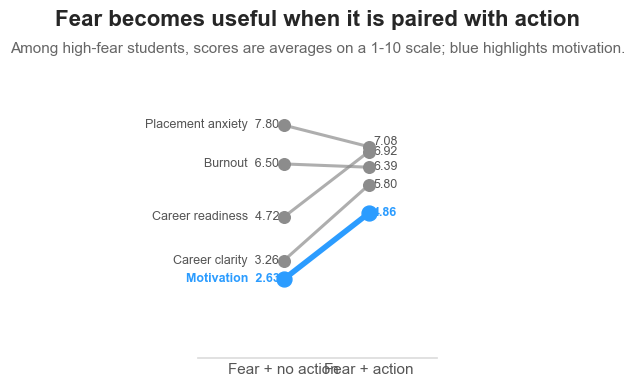

,metric,Fear + no action,Fear + action,difference
0,Career readiness,4.72,6.92,2.20
1,Career clarity,3.26,5.80,2.54
2,Motivation,2.63,4.86,2.22
3,Placement anxiety,7.80,7.08,-0.72
4,Burnout,6.50,6.39,-0.11


In [7]:
# =========================
# GRAFICA 04 - SLOPE GRAPH
# Que muestra: estudiantes con miedo a reemplazo de IA sin accion vs con accion.
# =========================

# --- VARIABLES / GRUPOS: cambia estos grupos si quieres otra comparacion.
left_group = fear_no_action
right_group = fear_action
left_label = "Fear + no action"
right_label = "Fear + action"
metrics_to_plot = core_metrics

# --- TEXTOS Y SALIDA: cambia titulo, subtitulo y archivo PNG generado.
chart_title = "Fear becomes useful when it is paired with action"
chart_subtitle = "Among high-fear students, scores are averages on a 1-10 scale; blue highlights motivation."
output_filename = "04_slope_fear_action.png"

# --- COLORES GENERALES: gris base para lineas; usa line_color_overrides con OFFICIAL_BLUE para enfasis.
left_color = "#8c8c8c"
right_color = "#8c8c8c"
down_color = "#8c8c8c"
subtitle_color = "#666666"

# --- COLOR POR LINEA: descomenta o agrega metricas para cambiar colores.
line_color_overrides = {
    "Motivation": OFFICIAL_BLUE,
}

# --- OFFSETS DE ETIQUETAS: mueve SOLO textos si se enciman. Positivo sube, negativo baja.
label_y_offsets = {
    # "Career readiness": 0.10,
    # "Burnout": -0.12,
}

right_value_y_offsets = {
    "Placement anxiety": 0.17,
    # "Burnout": -0.10,
}

# --- LABEL DEL EJE Y: deja "" para quitarlo y tener estilo mas limpio.
y_axis_label = ""

# --- ESPACIADO / TAMANO: modifica tamano, baseline del eje Y y espacio horizontal.
fig_size = (5, 4)
y_limits = (0,10)
x_limits = (-1.00, 1.8)

comp_fear_action = create_comparison_df(
    left_group,
    right_group,
    left_label,
    right_label,
    metrics_to_plot,
    metric_labels
)

slope_graph(
    comp_fear_action,
    left_label,
    right_label,
    chart_title,
    output_filename,
    subtitle=chart_subtitle,
    left_color=left_color,
    right_color=right_color,
    down_color=down_color,
    line_color_overrides=line_color_overrides,
    subtitle_color=subtitle_color,
    label_y_offsets=label_y_offsets,
    y_axis_label=y_axis_label,
    figsize=fig_size,
    y_limits=y_limits,
    x_limits=x_limits,
    right_value_y_offsets=right_value_y_offsets
)

comp_fear_action.round(2)

**Insight:** En este dataset real, el miedo al reemplazo laboral se lee distinto cuando viene acompanado de accion. El grupo con accion muestra mayor motivacion, ademas de mejores senales de claridad y readiness.

## 6. Comparacion 3: alta dependencia de IA con o sin cursos de habilidades
### Skill courses turn dependency into motivation

Aqui filtramos estudiantes con alta dependencia de IA. La historia no se queda en dependencia como problema; muestra que los cursos de habilidades pueden cambiar la lectura. La linea azul destaca **Motivation**, el mayor aumento de esta comparacion.

In [8]:

high_dependency_cutoff = df["ai_dependency_score"].quantile(0.75)
high_dep = df[df["ai_dependency_score"] >= high_dependency_cutoff].copy()

dep_few_courses = high_dep[high_dep["skill_development_courses_taken"] <= low_courses_cutoff]
dep_more_courses = high_dep[high_dep["skill_development_courses_taken"] >= high_courses_cutoff]

print(f"High AI dependency cutoff: >= {high_dependency_cutoff:.1f} on a 1–10 scale")
print(f"High dependency + few courses students: {len(dep_few_courses):,}")
print(f"High dependency + more courses students: {len(dep_more_courses):,}")


High AI dependency cutoff: >= 6.0 on a 1–10 scale
High dependency + few courses students: 2,449
High dependency + more courses students: 1,519


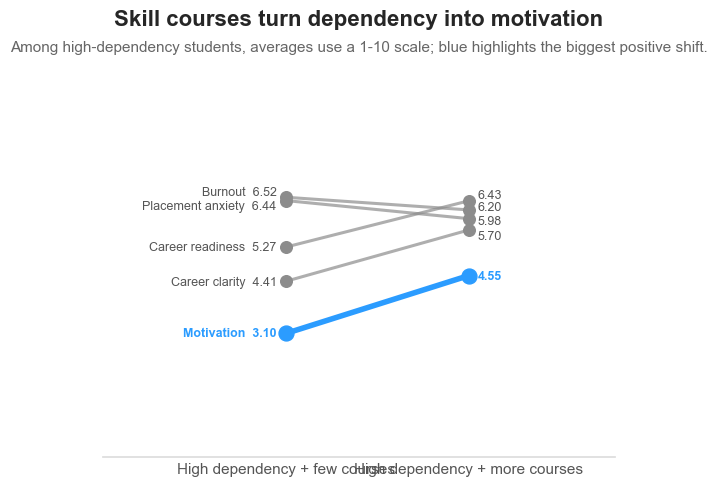

,metric,High dependency + few courses,High dependency + more courses,difference
0,Career readiness,5.27,6.43,1.16
1,Career clarity,4.41,5.70,1.29
2,Motivation,3.10,4.55,1.45
3,Placement anxiety,6.44,5.98,-0.45
4,Burnout,6.52,6.20,-0.32


In [9]:
# =========================
# GRAFICA 05 - SLOPE GRAPH
# Que muestra: alta dependencia con pocos vs mas cursos de habilidades.
# =========================

# --- VARIABLES: cambia la lista si quieres mostrar menos/mas metricas en esta grafica.
metrics_courses = [
    "overall_career_readiness_score",
    "career_clarity_score",
    "motivation_score",
    "placement_anxiety_score",
    "burnout_score"
]

# --- GRUPOS.
left_group = dep_few_courses
right_group = dep_more_courses
left_label = "High dependency + few courses"
right_label = "High dependency + more courses"
metrics_to_plot = metrics_courses

# --- TEXTOS Y SALIDA: cambia titulo, subtitulo y archivo PNG generado.
chart_title = "Skill courses turn dependency into motivation"
chart_subtitle = "Among high-dependency students, averages use a 1-10 scale; blue highlights the biggest positive shift."
output_filename = "05_slope_dependency_courses.png"

# --- COLORES GENERALES: gris base para lineas; usa line_color_overrides con OFFICIAL_BLUE para enfasis.
left_color = "#8c8c8c"
right_color = "#8c8c8c"
down_color = "#8c8c8c"
subtitle_color = "#666666"

# --- COLOR POR LINEA: descomenta o agrega metricas para cambiar colores.
line_color_overrides = {
    "Motivation": OFFICIAL_BLUE,
}

# --- OFFSETS DE ETIQUETAS: mueve SOLO textos si se enciman. Positivo sube, negativo baja.
label_y_offsets = {
    # "Career readiness": 0.10,
    "Burnout": .12,
    "Placement anxiety": -.12
}

right_value_y_offsets = {
    "Burnout": 0.06,
    "Placement anxiety": -0.06,
    "Career readiness": .15,
    "Career clarity": -0.15,
}

# --- LABEL DEL EJE Y: deja "" para quitarlo y tener estilo mas limpio.
y_axis_label = ""

# --- ESPACIADO / TAMANO: modifica tamano, baseline del eje Y y espacio horizontal.
fig_size = (7, 5)
y_limits = (0, 10)
x_limits = (-1.00, 1.8)

comp_courses = create_comparison_df(
    left_group,
    right_group,
    left_label,
    right_label,
    metrics_to_plot,
    metric_labels
)

slope_graph(
    comp_courses,
    left_label,
    right_label,
    chart_title,
    output_filename,
    subtitle=chart_subtitle,
    left_color=left_color,
    right_color=right_color,
    down_color=down_color,
    line_color_overrides=line_color_overrides,
    subtitle_color=subtitle_color,
    label_y_offsets=label_y_offsets,
    y_axis_label=y_axis_label,
    figsize=fig_size,
    y_limits=y_limits,
    x_limits=x_limits,
    right_value_y_offsets=right_value_y_offsets,
)

comp_courses.round(2)

**Insight:** La dependencia de IA no debe leerse de forma aislada. Entre estudiantes con alta dependencia, tomar mas cursos aparece asociado con una mejora clara en motivacion y mejores senales de preparacion.

## 7. Comparacion 4: uso intensivo de IA con o sin internship
### Internships are the clearest readiness signal

Esta comparacion conecta directamente con preparacion profesional. Incluso entre estudiantes con alto uso de IA, tener internship marca una diferencia fuerte. La linea azul destaca **Career readiness**.

In [10]:

high_ai_no_internship = high_ai[high_ai["internship_experience"] == 0]
high_ai_with_internship = high_ai[high_ai["internship_experience"] >= 1]

print(f"High AI + no internship students: {len(high_ai_no_internship):,}")
print(f"High AI + internship students: {len(high_ai_with_internship):,}")


High AI + no internship students: 525
High AI + internship students: 3,319


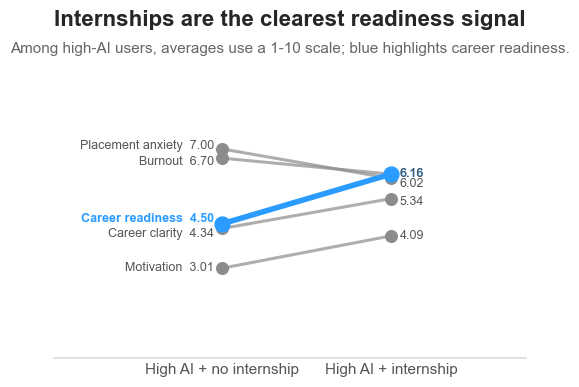

,metric,High AI + no internship,High AI + internship,difference
0,Career readiness,4.50,6.16,1.66
1,Career clarity,4.34,5.34,1.00
2,Motivation,3.01,4.09,1.08
3,Placement anxiety,7.00,6.02,-0.99
4,Burnout,6.70,6.16,-0.54


In [11]:
# =========================
# GRAFICA 06 - SLOPE GRAPH
# Que muestra: alto uso de IA sin internship vs con internship.
# =========================

# --- VARIABLES / GRUPOS.
left_group = high_ai_no_internship
right_group = high_ai_with_internship
left_label = "High AI + no internship"
right_label = "High AI + internship"
metrics_to_plot = core_metrics

# --- TEXTOS Y SALIDA: cambia titulo, subtitulo y archivo PNG generado.
chart_title = "Internships are the clearest readiness signal"
chart_subtitle = "Among high-AI users, averages use a 1-10 scale; blue highlights career readiness."
output_filename = "06_slope_high_ai_internship.png"

# --- COLORES GENERALES: gris base para lineas; usa line_color_overrides con OFFICIAL_BLUE para enfasis.
left_color = "#8c8c8c"
right_color = "#8c8c8c"
down_color = "#8c8c8c"
subtitle_color = "#666666"

# --- COLOR POR LINEA: descomenta o agrega metricas para cambiar colores.
line_color_overrides = {
    "Career readiness": OFFICIAL_BLUE,
}

# --- OFFSETS DE ETIQUETAS: mueve SOLO textos si se enciman. Positivo sube, negativo baja.
label_y_offsets = {
    "Placement anxiety": 0.12,
    "Burnout": -0.12,
    "Career readiness": .15,
    "Career clarity": -.17
}

right_value_y_offsets = {
    "Career clarity": -.1,
    "Placement anxiety": -0.2,
}

# --- LABEL DEL EJE Y: deja "" para quitarlo y tener estilo mas limpio.
y_axis_label = ""

# --- ESPACIADO / TAMANO: modifica tamano, baseline del eje Y y espacio horizontal.
fig_size = (6, 4)
y_limits = (0, 10)
x_limits = (-1.00, 1.8)

comp_internship = create_comparison_df(
    left_group,
    right_group,
    left_label,
    right_label,
    metrics_to_plot,
    metric_labels
)

slope_graph(
    comp_internship,
    left_label,
    right_label,
    chart_title,
    output_filename,
    subtitle=chart_subtitle,
    left_color=left_color,
    right_color=right_color,
    down_color=down_color,
    line_color_overrides=line_color_overrides,
    subtitle_color=subtitle_color,
    label_y_offsets=label_y_offsets,
    y_axis_label=y_axis_label,
    figsize=fig_size,
    y_limits=y_limits,
    x_limits=x_limits,
    right_value_y_offsets=right_value_y_offsets
)

comp_internship.round(2)

**Insight:** La IA puede apoyar, pero la experiencia real sigue siendo clave. Entre high-AI users, quienes tienen internship muestran una mejora clara en readiness.

## 8. Comparacion 5: cuando la IA reemplaza el pensamiento propio
### When AI replaces thinking, motivation drops

Cerramos con el argumento central: usar IA no es el problema; el warning sign aparece cuando la IA reemplaza el pensamiento propio. La linea azul destaca **Motivation**, porque es la caida mas fuerte en esta comparacion.

In [12]:

low_replacement_cutoff = df["ai_replaces_own_thinking_score"].quantile(0.25)
high_replacement_cutoff = df["ai_replaces_own_thinking_score"].quantile(0.75)

low_replacement = df[df["ai_replaces_own_thinking_score"] <= low_replacement_cutoff]
high_replacement = df[df["ai_replaces_own_thinking_score"] >= high_replacement_cutoff]

print(f"Low replacement cutoff: <= {low_replacement_cutoff:.0f} on a 1–5 scale")
print(f"High replacement cutoff: >= {high_replacement_cutoff:.0f} on a 1–5 scale")
print(f"Low replacement students: {len(low_replacement):,}")
print(f"High replacement students: {len(high_replacement):,}")


Low replacement cutoff: <= 2 on a 1–5 scale
High replacement cutoff: >= 4 on a 1–5 scale
Low replacement students: 5,634
High replacement students: 5,451


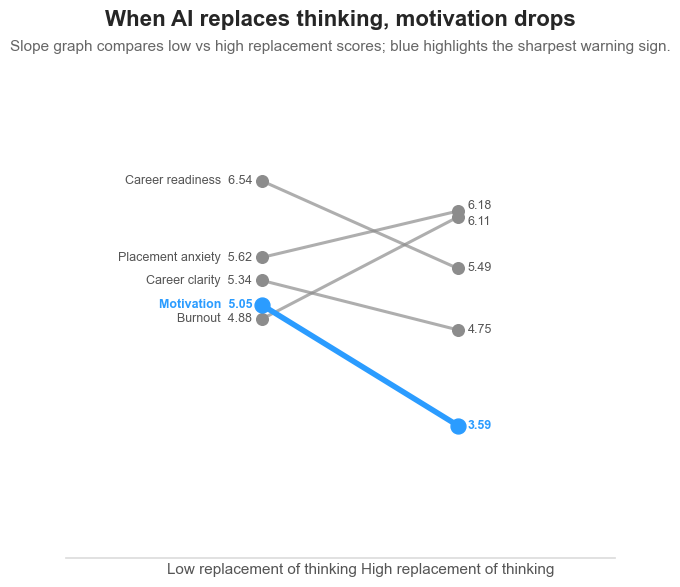

,metric,Low replacement of thinking,High replacement of thinking,difference
0,Career readiness,6.54,5.49,-1.05
1,Career clarity,5.34,4.75,-0.60
2,Motivation,5.05,3.59,-1.45
3,Placement anxiety,5.62,6.18,0.56
4,Burnout,4.88,6.11,1.23


In [13]:
# =========================
# GRAFICA 07 - SLOPE GRAPH
# Que muestra: bajo vs alto reemplazo del pensamiento propio.
# =========================

# --- VARIABLES / GRUPOS.
left_group = low_replacement
right_group = high_replacement
left_label = "Low replacement of thinking"
right_label = "High replacement of thinking"
metrics_to_plot = core_metrics

# --- TEXTOS Y SALIDA: cambia titulo, subtitulo y archivo PNG generado.
chart_title = "When AI replaces thinking, motivation drops"
chart_subtitle = "Slope graph compares low vs high replacement scores; blue highlights the sharpest warning sign."
output_filename = "07_slope_replacement_thinking.png"

# --- COLORES GENERALES: gris base para lineas; usa line_color_overrides con OFFICIAL_BLUE para enfasis.
left_color = "#8c8c8c"
right_color = "#8c8c8c"
down_color = "#8c8c8c"
subtitle_color = "#666666"

# --- COLOR POR LINEA: descomenta o agrega metricas para cambiar colores.
line_color_overrides = {
    "Motivation": OFFICIAL_BLUE,
}

# --- OFFSETS DE ETIQUETAS: mueve SOLO textos si se enciman. Positivo sube, negativo baja.
label_y_offsets = {
    # "Career readiness": 0.10,
    # "Burnout": -0.12,
}
right_value_y_offsets = {
    "Placement anxiety": 0.06,
    "Burnout": -0.06,
}

# --- LABEL DEL EJE Y: deja "" para quitarlo y tener estilo mas limpio.
y_axis_label = ""

# --- ESPACIADO / TAMANO: modifica tamano, baseline del eje Y y espacio horizontal.
fig_size = (7, 6)
y_limits = (2, 8)
x_limits = (-1.00, 1.8)

comp_replacement = create_comparison_df(
    left_group,
    right_group,
    left_label,
    right_label,
    metrics_to_plot,
    metric_labels
)

slope_graph(
    comp_replacement,
    left_label,
    right_label,
    chart_title,
    output_filename,
    subtitle=chart_subtitle,
    left_color=left_color,
    right_color=right_color,
    down_color=down_color,
    line_color_overrides=line_color_overrides,
    subtitle_color=subtitle_color,
    label_y_offsets=label_y_offsets,
    y_axis_label=y_axis_label,
    figsize=fig_size,
    y_limits=y_limits,
    x_limits=x_limits,
    right_value_y_offsets=right_value_y_offsets
)

comp_replacement.round(2)

**Insight:** Cuando la IA reemplaza mas el pensamiento propio, la motivacion cae con fuerza y tambien bajan readiness y claridad. Esta es la evidencia visual que sostiene la idea de la trampa de confianza.


## 10. Resumen de insights

1. **El uso de IA no debe interpretarse solo por horas.** El mismo nivel alto de uso puede verse distinto si el estudiante también desarrolla habilidades propias.
2. **El aprendizaje autónomo cambia la lectura del alto uso de IA.** Quienes usan mucha IA y también aprenden por fuera muestran mejores señales de preparación.
3. **El miedo al reemplazo puede transformarse en acción o en ansiedad.** La diferencia aparece cuando hay cursos, self-learning y desarrollo de habilidades.
4. **La experiencia práctica sigue siendo clave.** Entre estudiantes con alto uso de IA, quienes tienen internship muestran más readiness y claridad.
5. **La señal crítica es el reemplazo del pensamiento propio.** Cuando la IA sustituye el razonamiento del estudiante, aparecen peores indicadores de motivación, claridad y preparación.

**Conclusión:** La universidad no debería enfocarse en prohibir el uso de IA, sino en enseñar a usarla como herramienta de construcción de habilidades.


## 10. Storyboard para presentacion

| Slide | Titulo accionable | Visual | Mensaje | Linea/elemento azul |
|---|---|---|---|---|
| 1 | **More AI hours are linked to higher dependency** | Line graph | La entrada de la historia: conforme sube el uso diario de IA, tambien sube la dependencia promedio. | Ultimo cuartil de uso de IA |
| 2 | **Heavy AI users peak when dependency reaches its limit** | Line graph | Entre usuarios intensivos, el punto mas alto aparece cuando la dependencia llega al maximo. | Pico de mayor reemplazo del pensamiento |
| 3 | **Self-learning gives high-AI students clearer direction** | Slope graph | Alto uso de IA se interpreta mejor cuando hay aprendizaje autonomo. | Career clarity |
| 4 | **Fear becomes useful when it is paired with action** | Slope graph | El miedo puede convertirse en accion cuando hay aprendizaje y cursos. | Motivation |
| 5 | **Skill courses turn dependency into motivation** | Slope graph | Los cursos de habilidades cambian la lectura de la dependencia. | Motivation |
| 6 | **Internships are the clearest readiness signal** | Slope graph | La experiencia practica sigue siendo clave para readiness. | Career readiness |
| 7 | **When AI replaces thinking, motivation drops** | Slope graph | El riesgo aparece cuando la IA reemplaza el pensamiento propio. | Motivation |
| 8 | **Universities should teach AI as a skill-building tool** | Slide de recomendacion | La solucion es guiar el uso de IA, no prohibirlo. | Recomendacion final |

**Flujo narrativo:**

1. La IA ya forma parte del estudio diario, pero mas horas se asocian con mas dependencia.
2. En los usuarios intensivos, la dependencia alta coincide con el mayor reemplazo del pensamiento propio.
3. La historia cambia cuando aparecen senales de autonomia: aprendizaje propio, cursos, internships y claridad profesional.
4. Por eso la recomendacion no es prohibir IA, sino ensenar a usarla como herramienta para construir criterio y habilidades.


## 11. Recomendaciones para la audiencia

- Crear talleres de **AI literacy** donde los estudiantes aprendan a usar IA como apoyo al razonamiento.
- Integrar IA con programas de **career readiness**, no tratarla como una herramienta separada.
- Promover aprendizaje autónomo, cursos de habilidades, internships y práctica de entrevistas.
- Detectar estudiantes que usan IA intensivamente pero no están desarrollando habilidades propias.
- Evitar comunicar la IA como amenaza absoluta: el problema no es usarla, sino depender de ella sin construir capacidades.


## 12. Limitaciones

- El analisis es exploratorio y descriptivo.
- No se hacen afirmaciones causales.
- Los grupos comparados se crean solo para contar una historia visual y no representan diagnosticos.
- Para tomar decisiones institucionales reales se necesitarian encuestas validadas, revision etica y contexto adicional sobre la recoleccion de datos.


## 14. Reflexión

El principal reto fue evitar una historia demasiado simple como “más IA = más ansiedad”. Esa lectura era fácil, pero limitada. La versión final busca una historia más útil: el uso de IA puede ser positivo si se combina con aprendizaje autónomo, cursos, internships y claridad profesional. El diseño de las visualizaciones busca comparar comportamientos, no solo mostrar líneas que suben. Esto hace que el storytelling sea más humano, más accionable y más alineado con una audiencia universitaria.


In [14]:
# Save cleaned sample for submission in the project folder.
sample_path = Path(r"C:\Users\unbue\DataVizProject\ai_confidence_trap_comparison_clean_sample.csv")
df.sample(min(5000, len(df)), random_state=42).to_csv(sample_path, index=False)
print(f"Clean sample saved to: {sample_path}")
print(f"Figures saved to: {FIG_DIR}")

Clean sample saved to: C:\Users\unbue\DataVizProject\ai_confidence_trap_comparison_clean_sample.csv
Figures saved to: C:\Users\unbue\DataVizProject\figures
